In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd
from tensorflow import keras

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import time
import matplotlib
import matplotlib.ticker as mticker
import warnings


%matplotlib inline

%load_ext autoreload
%autoreload 2

2026-05-19 16:26:00.968383: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
HOME = "/home/thappe/" 

In [3]:
os.chdir(f"{HOME}HeaT")

from HeaT.TFrecord_utils_ERA_v2 import *
from HeaT.reconstruction import *

In [4]:
os.chdir(f"{HOME}/VAE3D/autoencoder_notebooks/LatentSpace/") 

from model.autoencoder_3d_model_v1 import CVAE
# from model.utils_3d import _parse_function_full, _parse_function

In [5]:
pwd

'/gpfs/home4/thappe/VAE3D/autoencoder_notebooks/LatentSpace'

In [6]:
os.chdir(HOME)

#GLOBAL VARIABLES - PATH
data_path = "/home/thappe/data/VAE_MODEL"
tf_record_path = "/home/thappe/data/tf_records/"

In [7]:
ls data/VAE_MODEL

entire_model_VAE/
ERA5_t2m_dynamic_encoded_heatwaves_L128.csv
ERA5_t2m_dynamic_heatwaves_dates.csv
ERA5_t2m_encoded_heatwaves_L128.csv
ERA5_t2m_heatwaves_dates.csv
ERA5_t2m_minus_thermo_encoded_heatwaves_L128.csv
ERA5_t2m_minus_thermo_heatwaves_dates.csv
GMM.pkl
Kmeanseucl.pkl
LENTIS_classes_VAE_L128_1000epochs.csv
LENTIS_Heatwave_means_VAE_L128_1000epochs.csv
VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


## LOADING DATA  ERA5

In [8]:
t2m_name = "t2m_minus_thermo" 

assert t2m_name in ["t2m", "t2m_dynamic", "t2m_minus_thermo"], "data not available for this var"

tf_record_file = f"{tf_record_path}/TF_record_ERA5_{t2m_name}_1940-2023_standardization_cut.tfrecord"

In [9]:
data = load_tfrecords_ERA5(tf_record_file)

In [10]:
#Get a sample to use for visualisation during training
data_testbatch = data.map(parse_function_full_era5).take(1) #selecting only one for visualisation

data_parsed = data.map(parse_function_full_era5)

In [11]:
data_testbatch


for element in data_testbatch.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    date = str(element[1]) + "_" + str(element[2]) + "_" + str(element[3]) 

2026-05-19 16:26:52.005309: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:370] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-05-19 16:26:52.037343: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## LOADING DATA LENTIS

In [12]:
ls /projects/einf4738/tf_records/files

TF_record_correctmask_ensemble101_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble102_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble103_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble104_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble105_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble106_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble107_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble108_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble109_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble110_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble111_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble112_NAext2_standardization_cut_noRSDS.tfrecord*
TF_record_correctmask_ensemble113_NAext2_standardization_cut_noR

In [13]:
os.chdir(f"{HOME}/VAE3D/autoencoder_notebooks/LatentSpace/") 

from model.utils_3d import _parse_function_full, _parse_function

In [14]:
def load_tfrecords_LENTIS(ensembles, norm_method='normalization'):
#     os.chdir(path)
    filenames = []
    if norm_method == 'standardized':
      norm_method = "0"
    for ens in ensembles:
        filenames.append(f"/projects/einf4738/tf_records/files/TF_record_correctmask_ensemble{ens}_NAext2_{norm_method}_noRSDS.tfrecord")
    data = tf.data.TFRecordDataset(filenames)
    return data

In [15]:
#load tf_records from lentis


#LOAD data from records
data_train_raw = load_tfrecords_LENTIS(np.arange(101,115,1), "standardization_cut")
data_val_raw = load_tfrecords_LENTIS(np.arange(115,117,1), "standardization_cut")


data_parsed_train = data_train_raw.map(_parse_function)
data_parsed_val = data_val_raw.map(_parse_function)

# Reconstruction and plotting - Figure 2B

How well are the ERA5 heatwaves reconstructed using the pre-trained VAE?

In [16]:
pwd

'/gpfs/home4/thappe/VAE3D/autoencoder_notebooks/LatentSpace'

In [17]:
VAE_model = (128, f"{data_path}/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5")

In [18]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

/home/thappe/data/VAE_MODEL/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


/sw/arch/RHEL9/EB_production/2024/software/TensorFlow/2.18.1-foss-2024a/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2026-05-19 16:27:01.355351: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


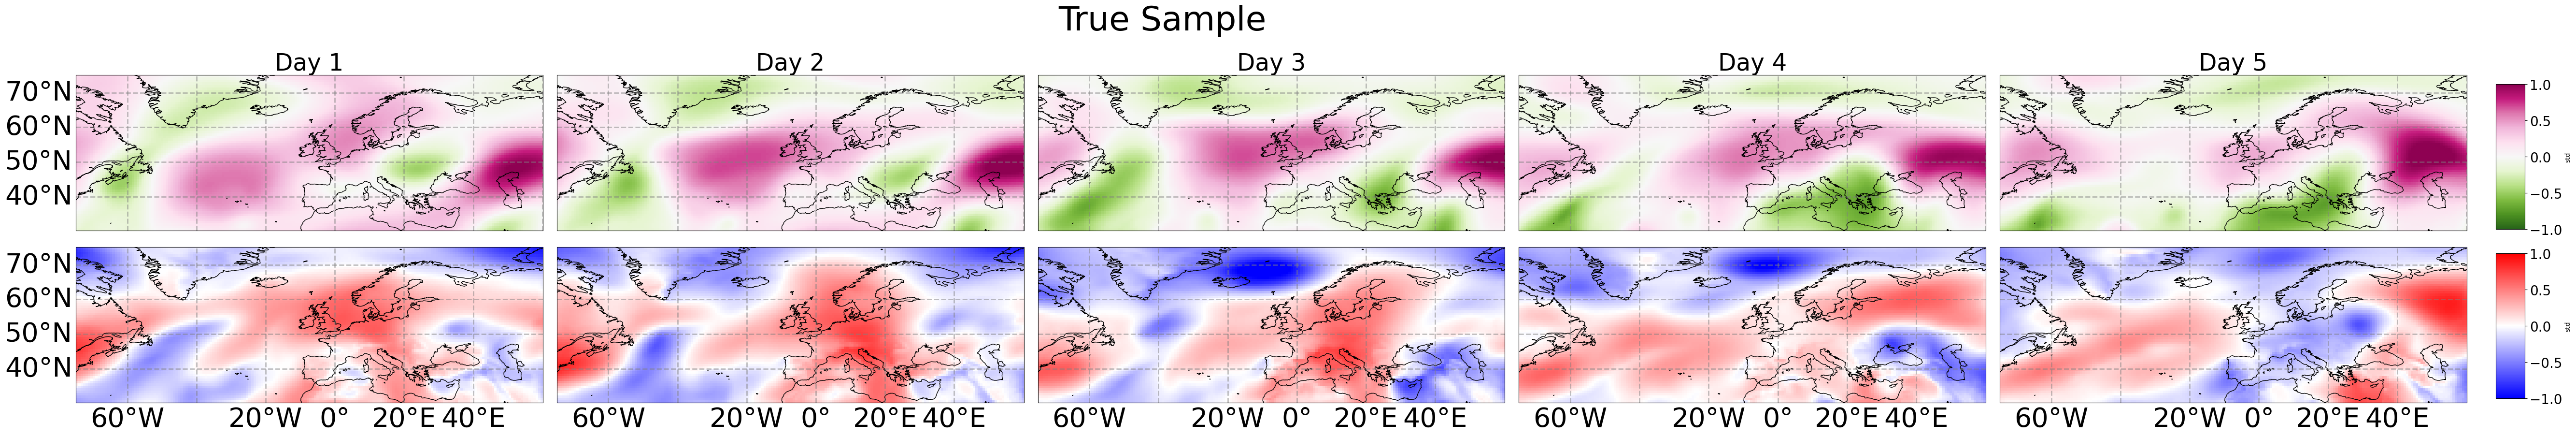

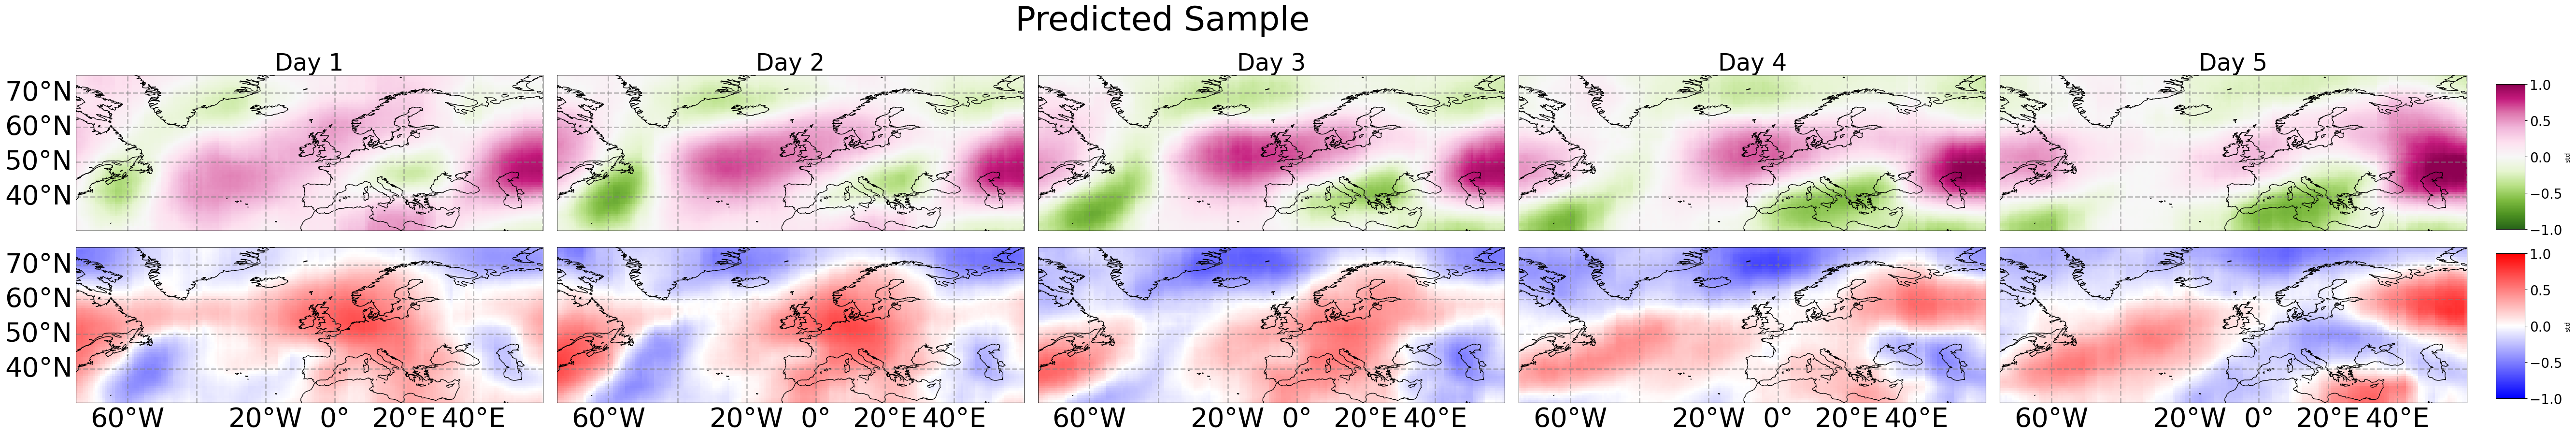

In [19]:
print(VAE_model[1])

%matplotlib inline

reconstruct_VAE_ERA5(VAE_model[1], VAE_model[0], data_testbatch)

# Get reconstruction error (R2) - Figure 2A

In [20]:
print(VAE_model[1])

r2_era5 = get_r2_reconstructed_ERA5(VAE_model[1], VAE_model[0], data_parsed)

/home/thappe/data/VAE_MODEL/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


In [23]:
r2_LENTIS_val = get_r2_reconstructed_ERA5(VAE_model[1], VAE_model[0], data_parsed_val)

2026-05-19 16:29:39.839975: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


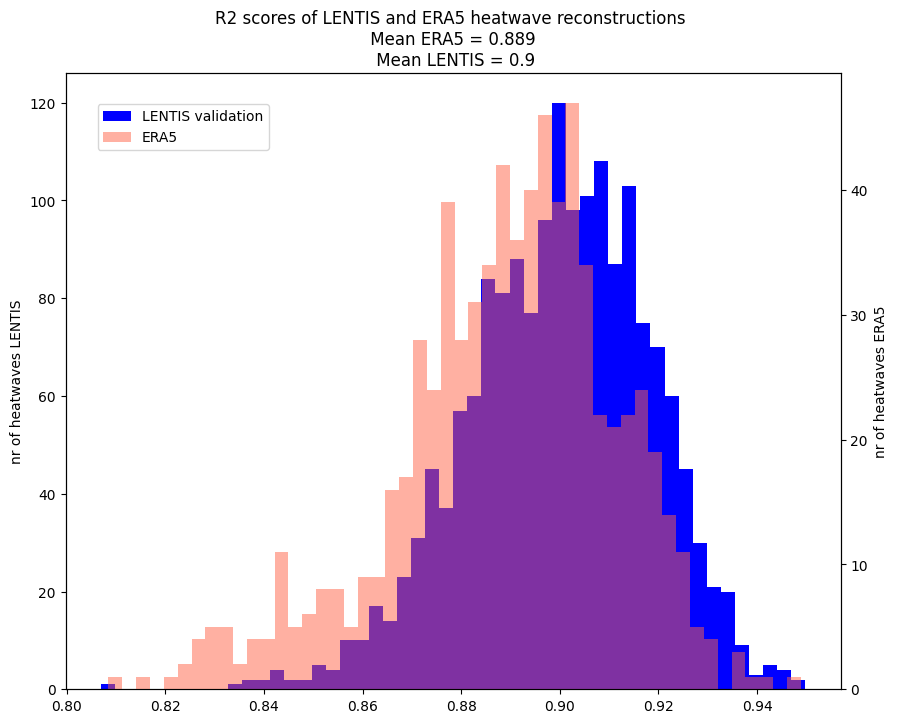

In [24]:
%matplotlib inline

fig, ax1 = plt.subplots(figsize=(10,8))

ax1.hist(r2_LENTIS_val, bins=50, color ="blue", label="LENTIS validation")
ax1.set_ylabel("nr of heatwaves LENTIS")
lentis_mean_rounded = round(np.mean(r2_LENTIS_val), 3)

ax2 = ax1.twinx()
ax2.hist(r2_era5, bins=50, label="ERA5", color="tomato", alpha=0.5)
ax2.set_ylabel("nr of heatwaves ERA5")
era5_mean_rounded = round(np.mean(r2_era5), 3)

plt.title(f"R2 scores of LENTIS and ERA5 heatwave reconstructions \n Mean ERA5 = {era5_mean_rounded} \n Mean LENTIS = {lentis_mean_rounded}")

fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.85))
plt.show()

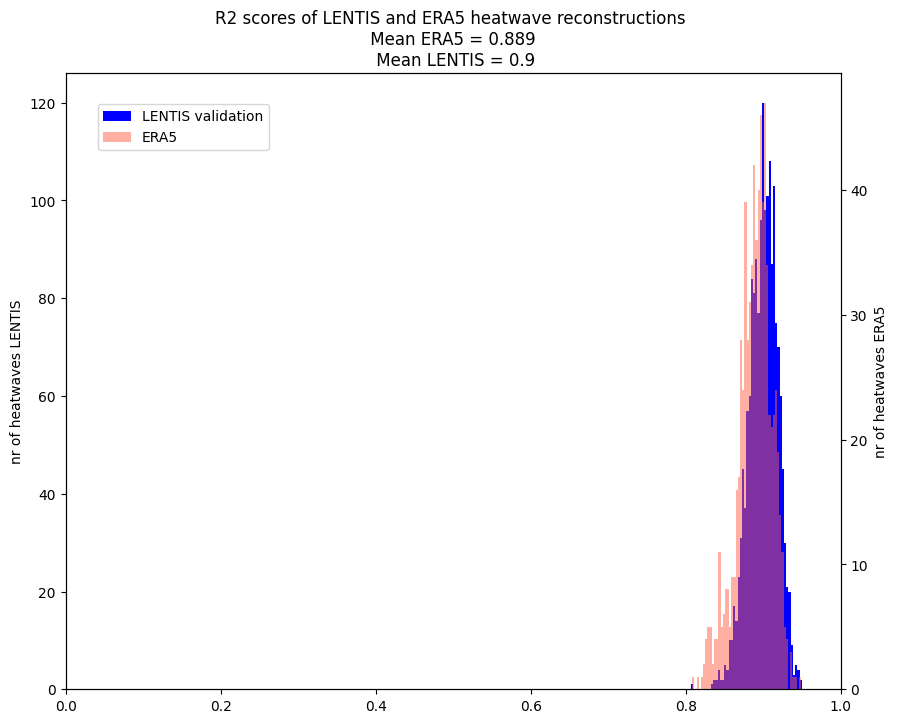

In [25]:
%matplotlib inline

fig, ax1 = plt.subplots(figsize=(10,8))

ax1.hist(r2_LENTIS_val, bins=50, color ="blue", label="LENTIS validation")
ax1.set_ylabel("nr of heatwaves LENTIS")
lentis_mean_rounded = round(np.mean(r2_LENTIS_val), 3)

ax2 = ax1.twinx()
ax2.hist(r2_era5, bins=50, label="ERA5", color="tomato", alpha=0.5)
ax2.set_ylabel("nr of heatwaves ERA5")
era5_mean_rounded = round(np.mean(r2_era5), 3)

ax1.set_xlim(0.0, 1.0)

plt.title(f"R2 scores of LENTIS and ERA5 heatwave reconstructions \n Mean ERA5 = {era5_mean_rounded} \n Mean LENTIS = {lentis_mean_rounded}")

fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.85))
plt.show()